<a href="https://colab.research.google.com/github/rmkenv/LinkedinWorks/blob/main/01_synthetic_energy_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔋 Post 01: Why Synthetic Data Might Be the Missing Piece in Grid Optimization

> *Companion notebook for the LinkedIn series: **Synthetic Data for Energy Management***

Real energy data is proprietary, sparse, or inconsistent. Synthetic data isn't a workaround — it's an unlock.

In this notebook we generate a **full year of synthetic building energy consumption** using:
- Seasonal Fourier components (annual + daily cycles)
- Occupancy-driven demand pulses (Gaussian mixture model)
- Weather-correlated cooling/heating loads
- Realistic noise injection

**Output:** A clean, labeled 8,760-row hourly dataset ready to train ML models — zero NDAs required.

---
| | |
|---|---|
| **Difficulty** | ⭐ Beginner |
| **Runtime** | ~2 min |
| **Libraries** | numpy, pandas, matplotlib, seaborn, scipy |
| **Data** | 100% synthetic — generated in notebook |

## 0. Install & Import

In [1]:
# All libraries are pre-installed in Colab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import norm
from scipy.signal import savgol_filter
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.prop_cycle': plt.cycler(color=['#1D9E75','#378ADD','#BA7517','#D4537E','#7F77DD'])
})

SEED = 42
rng = np.random.default_rng(SEED)
print('✅ Imports ready')

✅ Imports ready


## 1. Build the Time Index

In [2]:
# One full year at hourly resolution = 8,760 rows
YEAR = 2023
timestamps = pd.date_range(start=f'{YEAR}-01-01', end=f'{YEAR}-12-31 23:00', freq='h')
n = len(timestamps)

df = pd.DataFrame({'timestamp': timestamps})
df['hour']       = df.timestamp.dt.hour           # 0–23
df['day_of_week'] = df.timestamp.dt.dayofweek     # 0=Mon, 6=Sun
df['month']      = df.timestamp.dt.month          # 1–12
df['day_of_year'] = df.timestamp.dt.dayofyear     # 1–365
df['is_weekend'] = df.day_of_week >= 5
df = df.set_index('timestamp')

print(f'Time index: {timestamps[0]} → {timestamps[-1]}')
print(f'Total rows: {n:,} hourly observations')

Time index: 2023-01-01 00:00:00 → 2023-12-31 23:00:00
Total rows: 8,760 hourly observations


## 2. Seasonal Load Signal
We model a commercial office building in the mid-Atlantic US. HVAC dominates consumption —
peaking in summer (cooling) and winter (heating), with a spring/fall trough.

In [3]:
t = df['day_of_year'].values / 365.0  # normalized [0, 1]
h = df['hour'].values / 24.0          # normalized hour

# --- Annual seasonal envelope (HVAC) ---
# Two peaks: summer cooling (~day 196) and winter heating (~day 15)
summer_hvac = 35 * np.sin(np.pi * (df['day_of_year'].values - 80) / 185) ** 2
summer_hvac = np.where((df['day_of_year'].values > 80) & (df['day_of_year'].values < 265), summer_hvac, 0)

winter_hvac = 28 * np.cos(np.pi * df['day_of_year'].values / 60) ** 2
winter_hvac = np.where((df['day_of_year'].values < 60) | (df['day_of_year'].values > 300), winter_hvac, 0)

seasonal_hvac = summer_hvac + winter_hvac

# --- Diurnal base load (lighting + equipment) ---
# Morning ramp-up, lunch dip, afternoon peak, evening drop
diurnal = (
    20 * np.sin(np.pi * (df['hour'].values - 6) / 12) ** 2 *
    (df['hour'].values >= 6) * (df['hour'].values <= 20)
)
night_base = 8  # plug loads, security, servers

base_load = night_base + diurnal + seasonal_hvac

# Weekend reduction: 40% less demand
weekend_factor = np.where(df['is_weekend'].values, 0.6, 1.0)
base_load = base_load * weekend_factor

df['base_load_kw'] = base_load
print(f'Base load range: {base_load.min():.1f} – {base_load.max():.1f} kW')

Base load range: 4.8 – 63.0 kW


## 3. Occupancy-Driven Demand Pulses
Real buildings have micro-events: coffee runs, all-hands meetings, HVAC cycling.
We model these as a Gaussian Mixture process.

In [4]:
# Occupancy GMM: arrival wave (8-9am), lunch (12-1pm), afternoon (3-4pm)
def occupancy_pulse(hours, means, stds, weights, scale=15):
    pulse = np.zeros(len(hours))
    for mu, sigma, w in zip(means, stds, weights):
        pulse += w * norm.pdf(hours, mu, sigma)
    return pulse * scale / pulse.max()

hour_arr = df['hour'].values.astype(float)
occ_pulse = occupancy_pulse(
    hour_arr,
    means=[8.5, 13.0, 15.5],
    stds=[0.7, 0.5, 0.8],
    weights=[1.0, 0.6, 0.8]
)

# Zero out on weekends
occ_pulse = occ_pulse * (~df['is_weekend'].values)

# Random demand spikes (equipment startups, EV charging events)
n_spikes = 400
spike_idx = rng.integers(0, n, n_spikes)
spike_mag = rng.exponential(scale=8, size=n_spikes)  # kW, exponentially distributed
spikes = np.zeros(n)
spikes[spike_idx] = spike_mag

df['occupancy_kw'] = occ_pulse
df['spike_kw'] = spikes
print(f'Occupancy pulse peak: {occ_pulse.max():.1f} kW')
print(f'Demand spikes injected: {n_spikes} events, avg {spike_mag.mean():.1f} kW')

Occupancy pulse peak: 15.0 kW
Demand spikes injected: 400 events, avg 8.2 kW


## 4. Weather-Correlated Noise & Final Assembly

In [5]:
# Synthetic temperature: mid-Atlantic annual cycle
T_mean = 13  # °C annual mean (Baltimore-ish)
T_amp  = 14  # seasonal amplitude
temp_c = T_mean + T_amp * np.sin(2 * np.pi * (df['day_of_year'].values - 80) / 365)
temp_c += rng.normal(0, 2.5, n)  # daily weather noise
temp_c = savgol_filter(temp_c, 25, 3)  # smooth slightly

df['temp_c'] = temp_c

# Temperature sensitivity: extra load per degree above 22°C (cooling) or below 18°C (heating)
cooling_load = np.maximum(0, temp_c - 22) * 2.2   # kW per °C
heating_load = np.maximum(0, 18 - temp_c) * 1.8   # kW per °C

# Multiplicative noise (measurement + micro-variation)
noise = rng.normal(1.0, 0.04, n)  # ±4% noise

# Assemble final load
df['load_kw'] = (
    df['base_load_kw'] +
    df['occupancy_kw'] +
    df['spike_kw'] +
    cooling_load +
    heating_load
) * noise

# Clip to realistic range for a ~5,000 m² office
df['load_kw'] = df['load_kw'].clip(lower=5, upper=160)

print('\n📊 Synthetic dataset summary:')
print(df['load_kw'].describe().round(1))
print(f'\nTotal energy: {df["load_kw"].sum()/1000:.0f} MWh/year')


📊 Synthetic dataset summary:
count    8760.0
mean       41.7
std        19.6
min         6.5
25%        25.7
50%        40.7
75%        54.6
max       135.0
Name: load_kw, dtype: float64

Total energy: 365 MWh/year


## 5. Visualization 1 — Full Year Timeseries

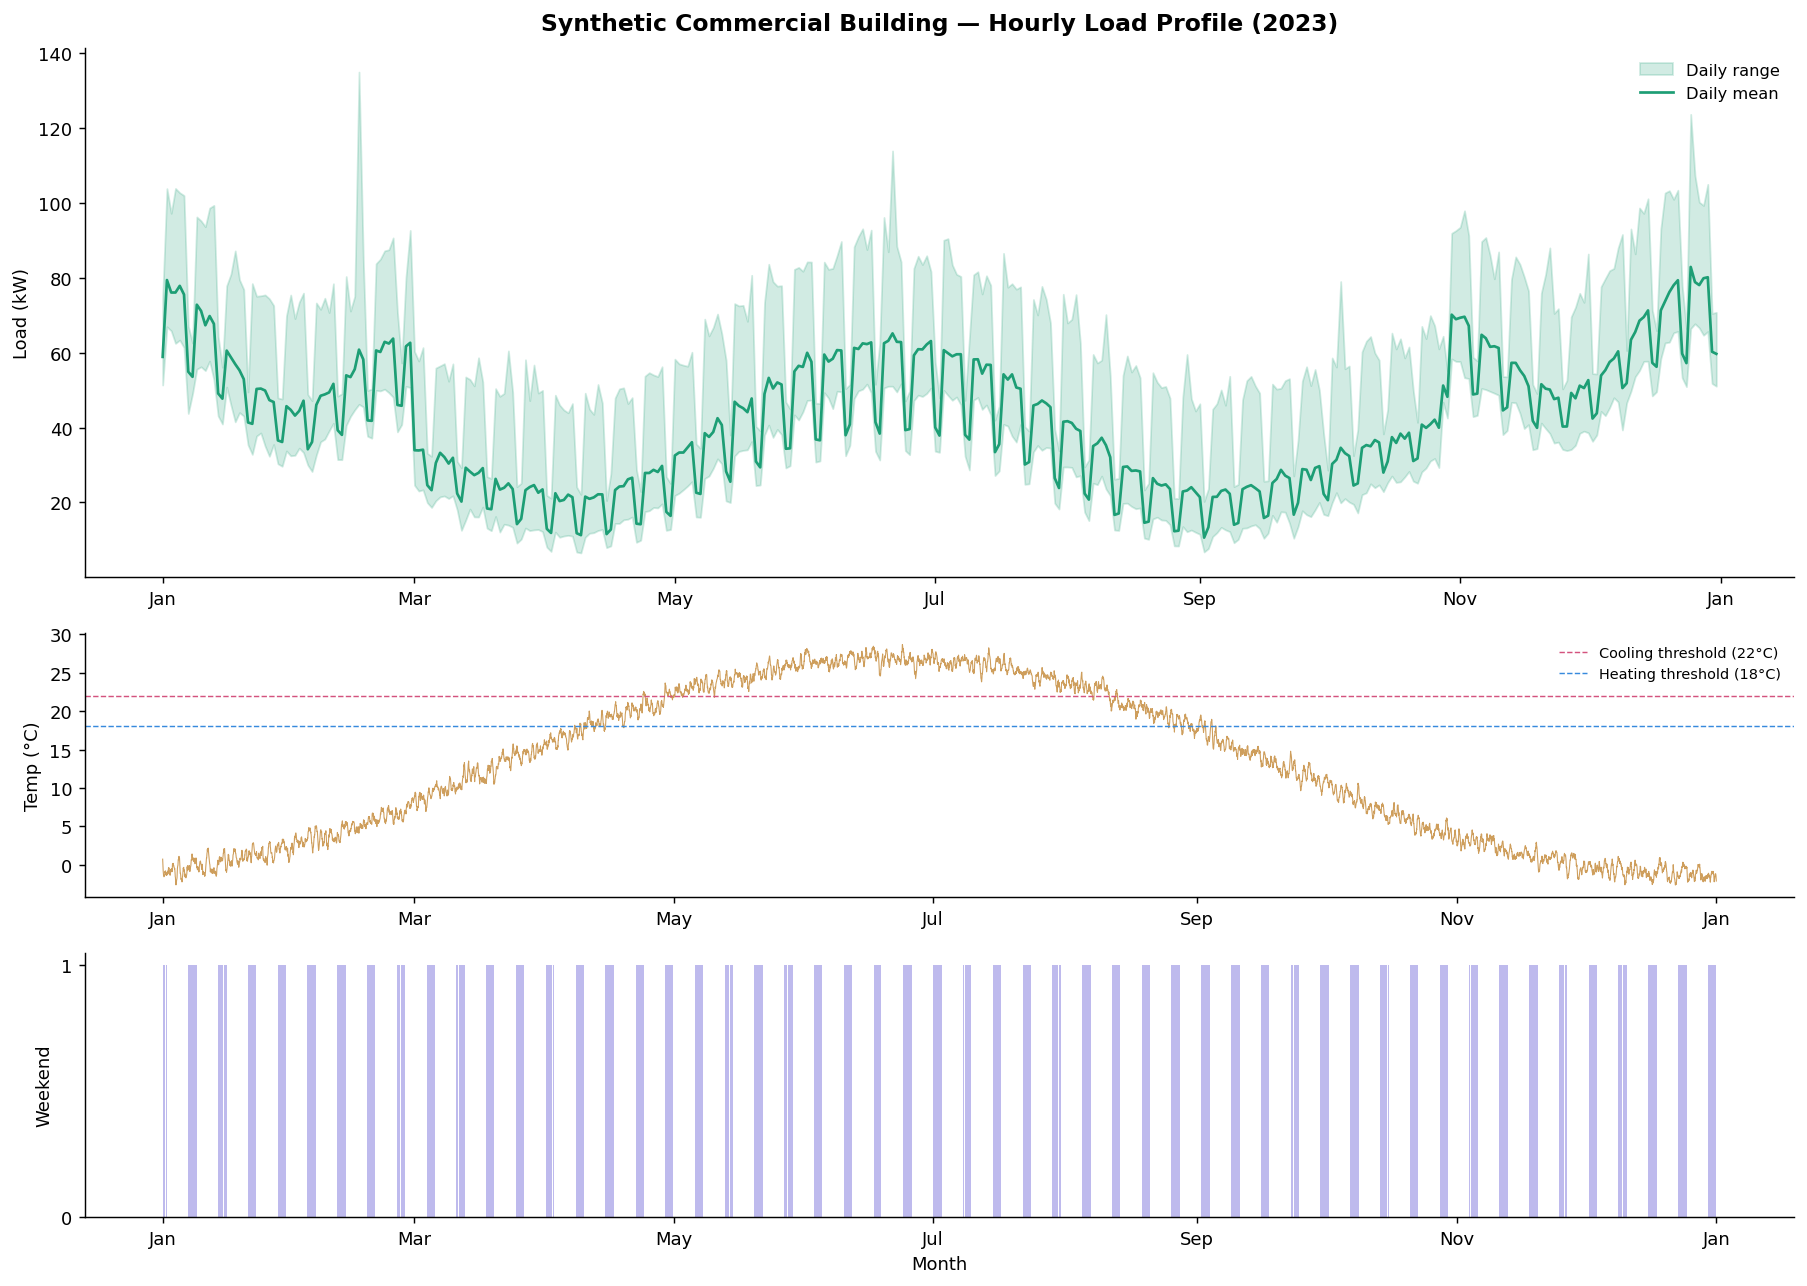

Figure saved: 01_full_year_load.png


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1.5, 1.5]})

# Panel 1: Full year load
ax = axes[0]
daily_mean = df['load_kw'].resample('D').mean()
daily_max  = df['load_kw'].resample('D').max()
daily_min  = df['load_kw'].resample('D').min()

ax.fill_between(daily_mean.index, daily_min, daily_max, alpha=0.2, color='#1D9E75', label='Daily range')
ax.plot(daily_mean.index, daily_mean, color='#1D9E75', linewidth=1.5, label='Daily mean')
ax.set_ylabel('Load (kW)')
ax.set_title('Synthetic Commercial Building — Hourly Load Profile (2023)', fontsize=13, fontweight='bold', pad=10)
ax.legend(frameon=False, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Panel 2: Temperature
ax2 = axes[1]
ax2.plot(df.index, df['temp_c'], color='#BA7517', linewidth=0.6, alpha=0.7)
ax2.axhline(22, color='#D4537E', linestyle='--', linewidth=0.8, label='Cooling threshold (22°C)')
ax2.axhline(18, color='#378ADD', linestyle='--', linewidth=0.8, label='Heating threshold (18°C)')
ax2.set_ylabel('Temp (°C)')
ax2.legend(frameon=False, fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Panel 3: Weekend vs Weekday flag
ax3 = axes[2]
ax3.bar(df.index, df['is_weekend'].astype(int), width=0.04, color='#7F77DD', alpha=0.5, label='Weekend')
ax3.set_ylabel('Weekend')
ax3.set_yticks([0, 1])
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax3.set_xlabel('Month')

plt.tight_layout()
plt.savefig('01_full_year_load.png', bbox_inches='tight')
plt.show()
print('Figure saved: 01_full_year_load.png')

## 6. Visualization 2 — Calendar Heatmap

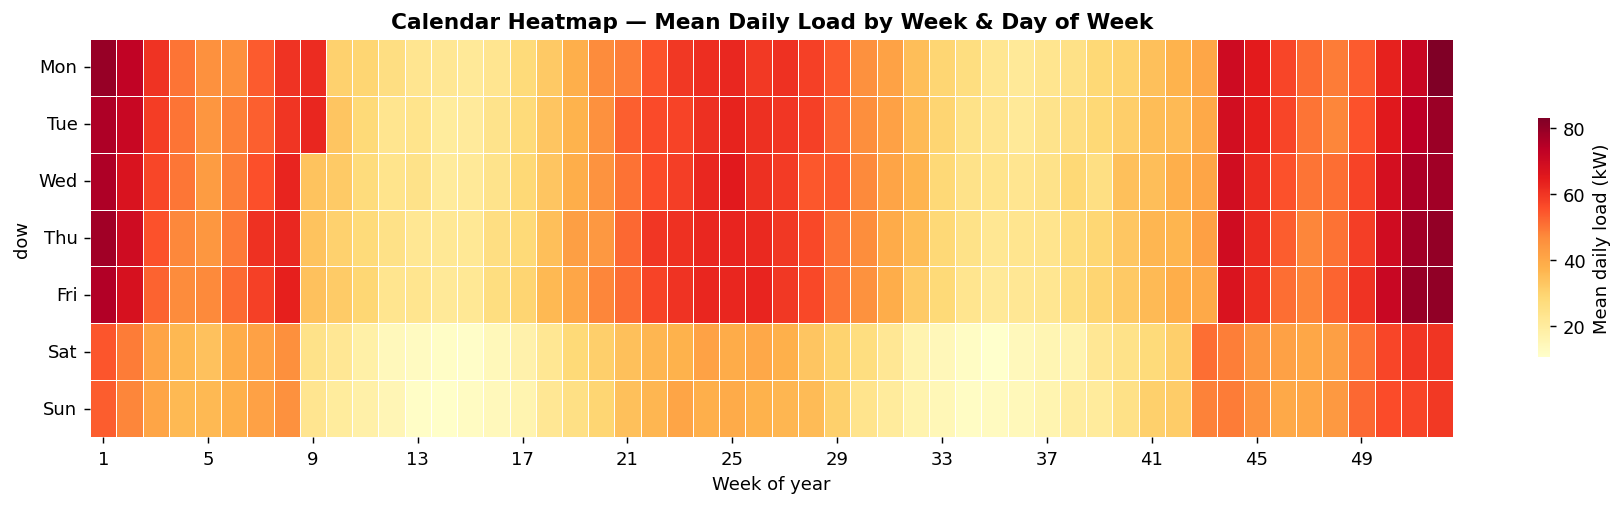

In [7]:
# Pivot to week × day_of_week grid for calendar heatmap
daily = df['load_kw'].resample('D').mean().reset_index()
daily.columns = ['date', 'load_kw']
daily['week'] = daily['date'].dt.isocalendar().week.astype(int)
daily['dow']  = daily['date'].dt.dayofweek

pivot = daily.pivot_table(index='week', columns='dow', values='load_kw', aggfunc='mean')

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    pivot.T,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Mean daily load (kW)', 'shrink': 0.6},
    xticklabels=4
)
ax.set_yticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)
ax.set_xlabel('Week of year')
ax.set_title('Calendar Heatmap — Mean Daily Load by Week & Day of Week', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('01_calendar_heatmap.png', bbox_inches='tight')
plt.show()

## 7. Visualization 3 — Load Duration Curve

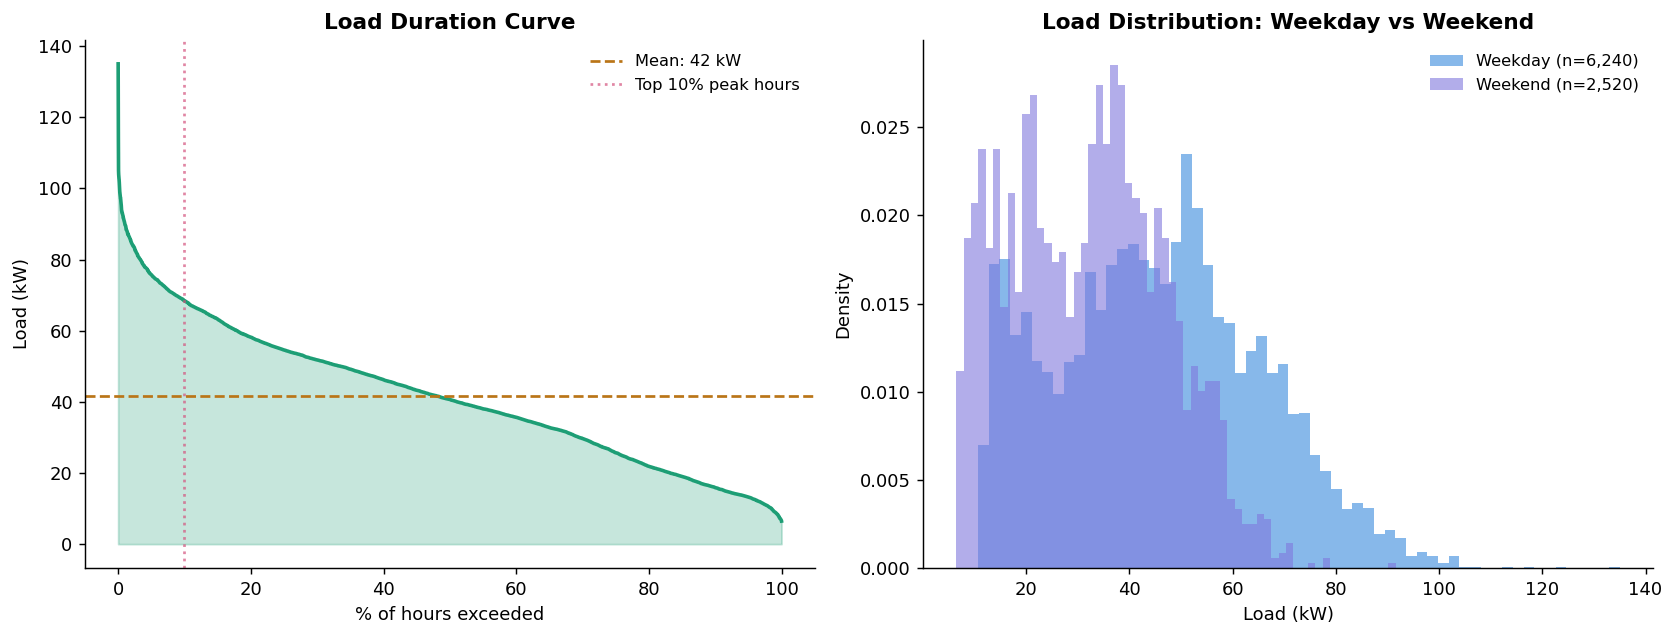

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Load duration curve
sorted_load = np.sort(df['load_kw'].values)[::-1]
pct_hours   = np.linspace(0, 100, len(sorted_load))

ax1.fill_between(pct_hours, sorted_load, alpha=0.25, color='#1D9E75')
ax1.plot(pct_hours, sorted_load, color='#1D9E75', linewidth=2)
ax1.axhline(sorted_load.mean(), color='#BA7517', linestyle='--', label=f'Mean: {sorted_load.mean():.0f} kW')
ax1.axvline(10, color='#D4537E', linestyle=':', alpha=0.7, label='Top 10% peak hours')
ax1.set_xlabel('% of hours exceeded')
ax1.set_ylabel('Load (kW)')
ax1.set_title('Load Duration Curve', fontweight='bold')
ax1.legend(frameon=False, fontsize=9)

# Distribution: weekday vs weekend
weekday = df.loc[~df['is_weekend'], 'load_kw']
weekend = df.loc[df['is_weekend'],  'load_kw']
ax2.hist(weekday, bins=60, alpha=0.6, color='#378ADD', density=True, label=f'Weekday (n={len(weekday):,})')
ax2.hist(weekend, bins=60, alpha=0.6, color='#7F77DD', density=True, label=f'Weekend (n={len(weekend):,})')
ax2.set_xlabel('Load (kW)')
ax2.set_ylabel('Density')
ax2.set_title('Load Distribution: Weekday vs Weekend', fontweight='bold')
ax2.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig('01_load_duration_curve.png', bbox_inches='tight')
plt.show()

## 8. Export Dataset

In [9]:
# Save clean CSV for use in subsequent notebooks
export_cols = ['load_kw', 'temp_c', 'hour', 'day_of_week', 'month', 'day_of_year', 'is_weekend']
df[export_cols].to_csv('synthetic_energy_2023.csv')
print(f'✅ Exported synthetic_energy_2023.csv — {len(df):,} rows × {len(export_cols)} columns')
print('\nColumn summary:')
print(df[export_cols].describe().round(2))

✅ Exported synthetic_energy_2023.csv — 8,760 rows × 7 columns

Column summary:
       load_kw   temp_c     hour  day_of_week    month  day_of_year
count  8760.00  8760.00  8760.00      8760.00  8760.00      8760.00
mean     41.67    12.98    11.50         3.01     6.53       183.00
std      19.59     9.98     6.92         2.00     3.45       105.37
min       6.47    -2.65     0.00         0.00     1.00         1.00
25%      25.69     3.09     5.75         1.00     4.00        92.00
50%      40.66    13.17    11.50         3.00     7.00       183.00
75%      54.58    23.11    17.25         5.00    10.00       274.00
max     135.02    28.67    23.00         6.00    12.00       365.00


## 9. Key Takeaways

✅ **What we built:** 8,760 rows of realistic synthetic energy data with seasonal HVAC loads, occupancy pulses, weather correlation, and demand spikes.

✅ **Why it works:** The generating process encodes domain knowledge — a model trained on this data will learn real patterns (morning ramp, weekend drop, summer peak) rather than noise.

✅ **What's next:** In Post 02, we feed this dataset into an LSTM and forecast demand 24 hours ahead.

---
*Part of the [Synthetic Data for Energy Management] LinkedIn series by Ryan Kmetz.*